# Treinamento CNN Pontinhos — V10 (Canais Estruturais)

Baseado em `Treinamento_CNN_Pontinhos_V9.ipynb`.

**Execucao**: PC local (Windows). Dados em `dados/profundidade_minimax_11_adaptativo`,
checkpoints e relatorios salvos em `resultados/jogo_pontinhos/`.

Com 32 GB de RAM o pipeline carrega todos os NPZs de uma vez, constroi
`X` e `y_soft` completos e faz o split — mesmo fluxo simples do V9.
Resultados e checkpoints sao salvos localmente (sem Google Drive).

In [15]:
# =========================================================================
# CONFIGURACAO — edite aqui antes de rodar
# =========================================================================
import os
import sys

def _find_root(start, marker='CLAUDE.md'):
    d = os.path.abspath(start)
    for _ in range(6):
        if os.path.exists(os.path.join(d, marker)):
            return d
        d = os.path.dirname(d)
    raise RuntimeError(f'Raiz do repositorio nao encontrada a partir de {start}')

ROOT = _find_root(os.getcwd())
if ROOT not in sys.path:
    sys.path.insert(0, ROOT)

# Pasta dos NPZs (originais + simetrias geradas pelo fase4)
PASTA_NPZ = os.path.join(ROOT, 'dados', 'profundidade_minimax_11_adaptativo')

# Pasta de resultados: checkpoint .keras, TFLite e relatorio .md
RESULTADO_DIR = os.path.join(ROOT, 'resultados', 'jogo_pontinhos')
os.makedirs(RESULTADO_DIR, exist_ok=True)

# Canais a incluir no treinamento (subconjunto dos 12 canonicos da Fase A.2).
# Use None para incluir todos os 12. A ordem define os indices no tensor de entrada.
CANAIS_TREINAMENTO = [
    'aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita',
    'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta',
    'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta',
    'paridade_cadeia_longa_impar'
]

# Para validacao Fase B (baseline 5 canais), substitua pela linha abaixo:
# CANAIS_TREINAMENTO = ['aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita', 'caixa_fechada']

# 'INCLUI_DUPLICADAS' (todas as amostras) ou 'DISTINTAS' (apenas matrizes unicas)
UTILIZACAO_MATRIZES = 'INCLUI_DUPLICADAS'

# USE_SAMPLE_WEIGHT = True: aplica peso por qtd_tracos (raro/frequente). False = sem peso.
USE_SAMPLE_WEIGHT = False

print(f'ROOT          = {ROOT}')
print(f'PASTA_NPZ     = {PASTA_NPZ}')
print(f'RESULTADO_DIR = {RESULTADO_DIR}')
print(f'Canais ({len(CANAIS_TREINAMENTO)}): {CANAIS_TREINAMENTO}')

ROOT          = d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend
PASTA_NPZ     = d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\dados\profundidade_minimax_11_adaptativo
RESULTADO_DIR = d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\resultados\jogo_pontinhos
Canais (12): ['aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita', 'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta', 'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta', 'paridade_cadeia_longa_impar']


In [16]:
import os
import glob

# --- GPU / CPU selector -------------------------------------------
# Para forcar CPU (caso GPU continue falhando), descomente:
# os.environ["CUDA_VISIBLE_DEVICES"] = "-1"
# ------------------------------------------------------------------
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
# cuda_malloc_async: allocator mais estavel no WDDM do Windows
os.environ["TF_GPU_ALLOCATOR"] = "cuda_malloc_async"

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers, Input
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

# GPU config: DEVE vir logo apos "import tensorflow as tf",
# antes de qualquer outra operacao TF.
# VirtualDeviceConfiguration faz UMA alocacao de 3 GB (mais compativel
# com WDDM do que set_memory_growth, que faz muitas alocacoes pequenas).
gpus = tf.config.list_physical_devices("GPU")
if gpus:
    try:
        tf.config.experimental.set_virtual_device_configuration(
            gpus[0],
            [tf.config.experimental.VirtualDeviceConfiguration(memory_limit=3072)]
        )
        print(f"GPU configurada: limite 3072 MB")
    except RuntimeError as e:
        print(f"Aviso GPU config: {e}")
else:
    print("Nenhuma GPU detectada — treinando em CPU.")

sns.set_theme(style="whitegrid")
np.random.seed(42)
tf.keras.utils.set_random_seed(42)

print("TensorFlow:", tf.__version__)
print("Dispositivos GPU:", tf.config.list_physical_devices("GPU"))


GPU configurada: limite 3072 MB
TensorFlow: 2.10.0
Dispositivos GPU: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


In [17]:
# =========================================================================
# CAPTURA DE RELATÓRIO — executar logo após a célula de imports
# rprint()        : imprime no terminal E grava no buffer do relatório .md.
# _md_h()         : cabeçalho markdown (## , ### …).
# _md_sep()       : linha separadora ---.
# _md_table()     : DataFrame → tabela markdown (requer tabulate, pré-instalado no Colab).
# _iniciar_secao(): reset de seção — re-execução segura de células individuais.
# =========================================================================
import io as _io_mod

_report_buf = _io_mod.StringIO()
_secao_pos: dict = {}  # checkpoint de posição no buffer por nome de seção

def rprint(*args, sep=' ', end='\n'):
    """Imprime no terminal e captura no buffer do relatório."""
    print(*args, sep=sep, end=end)
    msg = sep.join(str(a) for a in args) + end
    _report_buf.write(msg)

def _md_h(level: int, text: str):
    rprint('\n' + '#' * level + ' ' + text + '\n')

def _md_sep():
    rprint('\n---\n')

def _md_table(df, floatfmt='.4f', index=True):
    try:
        rprint(df.to_markdown(floatfmt=floatfmt, index=index))
    except Exception:
        rprint(df.to_string())
    rprint()

def _iniciar_secao(nome: str):
    """Volta ao checkpoint desta seção se ela já foi escrita antes.

    Permite re-executar qualquer célula de relatório sem duplicar conteúdo
    no buffer. Chame no início de cada célula que escreve no relatório.
    """
    if nome in _secao_pos:
        _report_buf.seek(_secao_pos[nome])
        _report_buf.truncate()
    _secao_pos[nome] = _report_buf.tell()

print('Captura de relatório ativada.')

Captura de relatório ativada.


In [18]:
# =========================================================================
# 1. LEITURA DOS DADOS
# =========================================================================
from datetime import datetime

# Ordem canonica dos 12 canais
NOMES_CANAIS_REF = (
    'aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita',
    'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta',
    'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta',
    'paridade_cadeia_longa_impar'
)

_canais_alvo = CANAIS_TREINAMENTO if CANAIS_TREINAMENTO is not None else list(NOMES_CANAIS_REF)
INDICES_CANAIS = [NOMES_CANAIS_REF.index(c) for c in _canais_alvo]
K = len(INDICES_CANAIS)
print(f'Canais para treino ({K}): {_canais_alvo}')
print(f'Indices no tensor (N,4,3,12): {INDICES_CANAIS}')

TRACOS_WEIGHTS = {
    1: 815.74,  2: 54.38,   3: 5.65,   4: 1.47,   5: 1.08,
    6: 1.02,    7: 1.01,    8: 1.00,   9: 1.00,   10: 1.00,
    11: 1.00,   12: 1.00,   13: 1.00,  14: 1.00,  15: 1.00,
    16: 1.00,   17: 1.00,   18: 1.01,  19: 1.03,  20: 1.07,
    21: 1.17,   22: 1.37,   23: 1.70,  24: 2.34,  25: 3.51,
    26: 6.32,   27: 14.58,  28: 41.05, 29: 150.52, 30: 815.74,
}

# =========================================================================
# 1.1 LEITURA DOS LOTES
# =========================================================================
arquivos_npz = sorted(glob.glob(os.path.join(PASTA_NPZ, '*.npz')))
print(f'\nEncontrados {len(arquivos_npz)} arquivos NPZ.')

lista_estados, lista_canais = [], []
lista_rotulos, lista_scores, lista_qtd_tracos, lista_cadeias = [], [], [], []
labels_canonicos = None

for arquivo in arquivos_npz:
    dados = np.load(arquivo, allow_pickle=True)
    lista_estados.append(dados['estados'])
    lista_canais.append(dados['canais'])
    lista_rotulos.append(dados['melhor_jogada'])
    lista_scores.append(dados['score_melhor_jogada'])
    lista_qtd_tracos.append(dados['qtd_tracos'])
    lista_cadeias.append(dados['qtd_cadeias_longas'])
    if labels_canonicos is None:
        labels_canonicos = dados['labels_canonicos'].tolist()

estados_raw     = np.concatenate(lista_estados,    axis=0)
canais_raw      = np.concatenate(lista_canais,     axis=0)
y_str           = np.concatenate(lista_rotulos,    axis=0)
scores_raw      = np.concatenate(lista_scores,     axis=0)
qtd_tracos_all  = np.concatenate(lista_qtd_tracos, axis=0).astype(np.int8)
qtd_cadeias_all = np.concatenate(lista_cadeias,    axis=0).astype(np.int8)

print(f'Total de amostras brutas: {len(canais_raw):,}')
_n_amostras_total = len(canais_raw)

# =========================================================================
# 1.2 FILTRAGEM DE DUPLICATAS (opcional)
# =========================================================================
if UTILIZACAO_MATRIZES == 'DISTINTAS':
    print('Filtrando apenas matrizes distintas...')
    _, unique_idx = np.unique(estados_raw.reshape(len(estados_raw), -1), axis=0, return_index=True)
    unique_idx.sort()
    canais_raw      = canais_raw[unique_idx]
    y_str           = y_str[unique_idx]
    scores_raw      = scores_raw[unique_idx]
    qtd_tracos_all  = qtd_tracos_all[unique_idx]
    qtd_cadeias_all = qtd_cadeias_all[unique_idx]
    print(f'Total apos filtragem (DISTINTAS): {len(canais_raw):,}')
del estados_raw

# =========================================================================
# 1.3 TENSOR DE ENTRADA
# =========================================================================
X = canais_raw[:, :, :, INDICES_CANAIS].astype(np.float32)
assert X.min() >= 0.0 and X.max() <= 1.0, 'ERRO: valores fora de {0,1}!'
print(f'Shape entrada: {X.shape[1:]} | dtype: {X.dtype}')

# =========================================================================
# 1.4 SOFT TARGETS
# =========================================================================
SCORE_IND = -1e9
label_to_idx       = {l: i for i, l in enumerate(labels_canonicos)}
num_classes        = len(labels_canonicos)
indice_para_rotulo = {i: l for i, l in enumerate(labels_canonicos)}
T = 1.0

def _build_soft(scores):
    n = len(scores)
    y = np.zeros((n, num_classes), dtype=np.float32)
    for i, sv in enumerate(scores):
        mask = sv > SCORE_IND
        if mask.sum() == 0:
            y[i] = 1.0 / num_classes
            continue
        vals = sv[mask] / T
        vals -= vals.max()
        exp_v = np.exp(vals)
        y[i, mask] = exp_v / exp_v.sum()
    return y

y_soft = _build_soft(scores_raw)

# =========================================================================
# 1.5 FASE DO JOGO
# =========================================================================
fase_jogo = np.digitize(qtd_tracos_all, bins=[12, 18, 24, 29]).astype(np.int8)
FASE_NAMES = {
    0: 'Abertura (0-11)',   1: '1a Metade (12-17)',
    2: '2a Metade (18-23)', 3: 'Fase Quente (24-28)', 4: 'Final (29-31)',
}

# =========================================================================
# 1.6 SPLIT (estratificado por fase)
# =========================================================================
idx_all = np.arange(len(X))
idx_tv, idx_test = train_test_split(
    idx_all, test_size=0.15, random_state=42, stratify=fase_jogo)
idx_train, idx_val = train_test_split(
    idx_tv, test_size=0.15/0.85, random_state=42, stratify=fase_jogo[idx_tv])

X_train, X_val, X_test = X[idx_train], X[idx_val], X[idx_test]
y_train, y_val, y_test = y_soft[idx_train], y_soft[idx_val], y_soft[idx_test]
del X, y_soft

# =========================================================================
# 1.7 METADADOS DO CONJUNTO DE TESTE
# =========================================================================
y_test_idx   = y_test.argmax(axis=1)
S_test       = scores_raw[idx_test]
fase_test    = fase_jogo[idx_test]
tracos_test  = qtd_tracos_all[idx_test]
cadeias_test = qtd_cadeias_all[idx_test]
canais_test  = canais_raw[idx_test]        # int8, todos os 12 canais (Tabela 1)
del scores_raw, canais_raw

# =========================================================================
# 1.8 SAMPLE WEIGHT (opcional)
# =========================================================================
if USE_SAMPLE_WEIGHT:
    qtd_treino = qtd_tracos_all[idx_train]
    sw_raw = np.array([TRACOS_WEIGHTS.get(int(t), 1.0) for t in qtd_treino], dtype=np.float32)
    sw = np.clip(sw_raw, 0.0, 20.0)
else:
    sw = None

import gc as _gc
_gc.collect()
print(f'Memoria — X_train: {X_train.nbytes/1e9:.2f} GB | '
      f'X_val: {X_val.nbytes/1e9:.2f} GB | X_test: {X_test.nbytes/1e9:.2f} GB')

# --- Report: cabecalho + dados de treinamento ---
_iniciar_secao('dados')
_md_h(1, 'Relatorio de Treinamento — BoxNet V10')
rprint('| Parametro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Data | {datetime.now().strftime("%Y-%m-%d %H:%M")} |')
rprint(f'| Canais ({len(_canais_alvo)}) | {", ".join(_canais_alvo)} |')
rprint(f'| PASTA_NPZ | `{PASTA_NPZ}` |')
rprint(f'| UTILIZACAO_MATRIZES | {UTILIZACAO_MATRIZES} |')
rprint(f'| USE_SAMPLE_WEIGHT | {USE_SAMPLE_WEIGHT} |')
rprint()

_md_h(2, '1. Dados de Treinamento')
rprint('| Parametro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Arquivos NPZ | {len(arquivos_npz)} |')
rprint(f'| Total de amostras | {_n_amostras_total:,} |')
rprint(f'| Treino | {len(X_train):,} |')
rprint(f'| Validacao | {len(X_val):,} |')
rprint(f'| Teste | {len(X_test):,} |')
rprint()

_dist = pd.DataFrame({
    'Treino (%)': pd.Series(fase_jogo[idx_train]).value_counts(normalize=True).sort_index() * 100,
    'Val (%)':    pd.Series(fase_jogo[idx_val]).value_counts(normalize=True).sort_index() * 100,
    'Teste (%)':  pd.Series(fase_jogo[idx_test]).value_counts(normalize=True).sort_index() * 100,
}).round(1)
_dist.index = [FASE_NAMES[i] for i in _dist.index]
_dist.index.name = 'Fase'
rprint('**Distribuicao por fase (%)**\n')
_md_table(_dist, floatfmt='.1f')
_md_sep()

Canais para treino (12): ['aresta_topo', 'aresta_base', 'aresta_esquerda', 'aresta_direita', 'caixa_fechada', 'eh_grau3', 'eh_grau2', 'em_cadeia_curta', 'em_cadeia_longa', 'em_loop', 'em_cadeia_aberta_uma_ponta', 'paridade_cadeia_longa_impar']
Indices no tensor (N,4,3,12): [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11]

Encontrados 1676 arquivos NPZ.
Total de amostras brutas: 13,693,840
Shape entrada: (4, 3, 12) | dtype: float32
Memoria — X_train: 5.52 GB | X_val: 1.18 GB | X_test: 1.18 GB

# Relatorio de Treinamento — BoxNet V10

| Parametro | Valor |
|-----------|-------|
| Data | 2026-05-27 12:30 |
| Canais (12) | aresta_topo, aresta_base, aresta_esquerda, aresta_direita, caixa_fechada, eh_grau3, eh_grau2, em_cadeia_curta, em_cadeia_longa, em_loop, em_cadeia_aberta_uma_ponta, paridade_cadeia_longa_impar |
| PASTA_NPZ | `d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\dados\profundidade_minimax_11_adaptativo` |
| UTILIZACAO_MATRIZES | INCLUI_DUPLICADAS |
| USE_SAMPLE_WEIGHT | False |


##

In [19]:
# === OVERFIT DIAGNÓSTICO: 50k da 1ª Metade — NÃO executar no treino normal ===
TAMANHO_OVERFIT = 50_000
qtd_treino = qtd_tracos_all[idx_train]
qtd_val    = qtd_tracos_all[idx_val]
mask_treino  = (qtd_treino >= 12) & (qtd_treino <= 17)
mask_val     = (qtd_val    >= 12) & (qtd_val    <= 17)
mask_teste   = (tracos_test >= 12) & (tracos_test <= 17)

rng = np.random.default_rng(42)
idx_overfit = np.where(mask_treino)[0]
sel = np.sort(rng.choice(idx_overfit, size=min(TAMANHO_OVERFIT, len(idx_overfit)), replace=False))

X_train = X_train[sel];      y_train = y_train[sel]
X_val   = X_val[mask_val];   y_val   = y_val[mask_val]
X_test  = X_test[mask_teste]; y_test = y_test[mask_teste]
y_test_idx   = y_test.argmax(axis=1)
S_test       = S_test[mask_teste]
fase_test    = fase_test[mask_teste]
tracos_test  = tracos_test[mask_teste]
cadeias_test = cadeias_test[mask_teste]
canais_test  = canais_test[mask_teste]
sw = None

print(f'OVERFIT: treino={len(X_train):,} | val={len(X_val):,} | teste={len(X_test):,}')

OVERFIT: treino=50,000 | val=410,818 | teste=410,817


In [20]:
# =========================================================================
# 2. ARQUITETURA BoxNet v3 — V8 (sem Lambda, input (4,3,K))
# =========================================================================

def bloco_residual_separavel(x, filtros, l2=2e-4, dropout=0.15):
    atalho = x
    y = layers.SeparableConv2D(
        filtros, (3, 3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2),
        pointwise_regularizer=regularizers.l2(l2),
    )(x)
    y = layers.BatchNormalization()(y)
    y = layers.Activation('relu')(y)
    y = layers.SpatialDropout2D(dropout)(y)
    y = layers.SeparableConv2D(
        filtros, (3, 3), padding='same', use_bias=False,
        depthwise_regularizer=regularizers.l2(l2),
        pointwise_regularizer=regularizers.l2(l2),
    )(y)
    y = layers.BatchNormalization()(y)
    if atalho.shape[-1] != filtros:
        atalho = layers.Conv2D(filtros, (1, 1), padding='same', use_bias=False,
                               kernel_regularizer=regularizers.l2(l2))(atalho)
        atalho = layers.BatchNormalization()(atalho)
    out = layers.Add()([y, atalho])
    out = layers.Activation('relu')(out)
    return out


#L2 = 2e-4
L2 = 0.0 # Teste de OVERFIT - Regularização Desligada
INPUT_SHAPE = (4, 3, K)

inputs = Input(shape=INPUT_SHAPE, name='canais_estruturais')
x = layers.Conv2D(32, (3, 3), padding='same', use_bias=False,
                  kernel_regularizer=regularizers.l2(L2))(inputs)
x = layers.BatchNormalization()(x)
x = layers.Activation('relu')(x)
#x = bloco_residual_separavel(x, 32, l2=L2, dropout=0.15)
#x = bloco_residual_separavel(x, 48, l2=L2, dropout=0.20)
x = bloco_residual_separavel(x, 32, l2=L2, dropout=0.0) # Teste de OVERFIT - Dropout desligado
x = bloco_residual_separavel(x, 48, l2=L2, dropout=0.0) # Teste de OVERFIT - Dropout desligado
gap  = layers.GlobalAveragePooling2D()(x)
flat = layers.Flatten()(x)
h    = layers.Concatenate()([gap, flat])
h    = layers.Dense(96, activation='relu', kernel_regularizer=regularizers.l2(L2))(h)
h    = layers.BatchNormalization()(h)
h    = layers.Dropout(0.5)(h)
outputs = layers.Dense(num_classes, activation='softmax',
                       kernel_regularizer=regularizers.l2(L2),
                       name='jogada')(h)

model = models.Model(inputs, outputs, name=f'BoxNet_v3_V8_{K}canais')
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss=tf.keras.losses.KLDivergence(),
    metrics=[
        tf.keras.metrics.CategoricalAccuracy(name='accuracy'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=3, name='top3_acc'),
        tf.keras.metrics.TopKCategoricalAccuracy(k=5, name='top5_acc'),
    ],
)

# Exibição normal no Colab (pode aparecer truncada — não importa)
model.summary()

# -------------------------------------------------------------------------
# Helpers para tabela de camadas — compatíveis com Keras 2 e Keras 3.
#
# Diferença crítica entre versões:
#   Keras 2 (TF < 2.16): tensor.shape → TensorShape, possui .as_list()
#                         node.inbound_layers → objetos Layer
#   Keras 3 (TF ≥ 2.16): tensor.shape → Python tuple pura, sem .as_list()
#                         node.inbound_layers → inexistente; usar
#                         tensor._keras_history.operation
# -------------------------------------------------------------------------

def _shape_str(shape_obj):
    """'(None, 4, 3, 32)' a partir de TensorShape ou tuple Python."""
    if hasattr(shape_obj, 'as_list'):          # Keras 2 / TensorShape
        return str(tuple(shape_obj.as_list()))
    return str(tuple(shape_obj))               # Keras 3 / Python tuple

def _layer_out_shape(layer):
    nodes = getattr(layer, '_inbound_nodes', [])
    if nodes:
        try:
            t = nodes[-1].output_tensors
            if isinstance(t, (list, tuple)):
                t = t[0] if len(t) > 0 else None
            if t is None:
                return '—'
            return _shape_str(t.shape)
        except Exception:
            return '—'
    # InputLayer: sem inbound nodes
    try:
        return _shape_str(layer.output.shape)
    except Exception:
        return '—'

def _layer_connected_to(layer):
    nodes = getattr(layer, '_inbound_nodes', [])
    if not nodes:
        return '—'
    node = nodes[-1]

    # Keras 2: node.inbound_layers → objetos Layer com .name
    in_layers = getattr(node, 'inbound_layers', None)
    if in_layers is not None:
        if isinstance(in_layers, (list, tuple)):
            return ', '.join(l.name for l in in_layers if hasattr(l, 'name'))
        if hasattr(in_layers, 'name'):
            return in_layers.name

    # Keras 3: input_tensors[i]._keras_history.operation.name
    try:
        in_tensors = getattr(node, 'input_tensors', None) or []
        if not isinstance(in_tensors, (list, tuple)):
            in_tensors = [in_tensors]
        seen, names = set(), []
        for t in in_tensors:
            hist = getattr(t, '_keras_history', None)
            op = getattr(hist, 'operation', None) or getattr(hist, 'layer', None)
            if op is not None and hasattr(op, 'name') and op.name not in seen:
                names.append(op.name)
                seen.add(op.name)
        if names:
            return ', '.join(names)
    except Exception:
        pass

    return '—'

# -------------------------------------------------------------------------
# Constrói a tabela e grava no relatório
# -------------------------------------------------------------------------
_layers_rows = []
for _layer in model.layers:
    _layers_rows.append({
        'Camada': _layer.name,
        'Tipo': _layer.__class__.__name__,
        'Output Shape': _layer_out_shape(_layer),
        'Param #': f'{_layer.count_params():,}',
        'Connected to': _layer_connected_to(_layer),
        'Treinável': _layer.trainable,
    })

# --- Report: arquitetura ---
_iniciar_secao('arquitetura')
_md_h(2, '2. Arquitetura')
rprint('| Parâmetro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Modelo | {model.name} |')
rprint(f'| Input shape | {INPUT_SHAPE} |')
rprint(f'| Parâmetros treináveis | {model.count_params():,} |')
rprint(f'| Classes | {num_classes} |')
rprint(f'| Loss | KL Divergence |')
rprint(f'| Optimizer | Adam (lr=1e-3) |')
rprint(f'| L2 regularização | {L2} |')
rprint(f'| Batch size | 256 |')
rprint(f'| EarlyStopping patience | 10 |')
rprint(f'| ReduceLROnPlateau patience | 6 |')
rprint()
rprint('**Estrutura das Camadas:**\n')
_md_table(pd.DataFrame(_layers_rows), index=False)
_md_sep()

Model: "BoxNet_v3_V8_12canais"
__________________________________________________________________________________________________
 Layer (type)                   Output Shape         Param #     Connected to                     
 canais_estruturais (InputLayer  [(None, 4, 3, 12)]  0           []                               
 )                                                                                                
                                                                                                  
 conv2d_2 (Conv2D)              (None, 4, 3, 32)     3456        ['canais_estruturais[0][0]']     
                                                                                                  
 batch_normalization_7 (BatchNo  (None, 4, 3, 32)    128         ['conv2d_2[0][0]']               
 rmalization)                                                                                     
                                                                              

In [21]:
# =========================================================================
# 3. TREINAMENTO
# =========================================================================
_iniciar_secao('treinamento')
_md_h(2, '3. Treinamento')

from tensorflow.keras.callbacks import ModelCheckpoint

#_ckpt_path = os.path.join(RESULTADO_DIR, f'BoxNet_V10_{K}canais_best_valloss.keras')
_ckpt_path = os.path.join(RESULTADO_DIR, f'BoxNet_V10_{K}canais_OVERFIT.keras') # Teste de Overfit

if os.path.exists(_ckpt_path):
    # Recuperacao: checkpoint ja existe — pula treinamento e carrega pesos salvos.
    print(f'Checkpoint encontrado: {_ckpt_path}')
    print('Carregando modelo salvo (treinamento pulado)...')
    with tf.device('/CPU:0'):
        model = tf.keras.models.load_model(_ckpt_path)
    history = None
    rprint('*(modelo carregado de checkpoint — treinamento pulado)*\n')
    rprint('| Metrica | Valor |')
    rprint('|---------|-------|')
    rprint(f'| Checkpoint | `{os.path.basename(_ckpt_path)}` |')
    rprint()
    print('Modelo carregado. Pronto para avaliacao (celulas seguintes).')
else:
    # Treinamento normal do zero.
    rprint('*(logs de epoca omitidos do relatorio — ver notebook)*\n')
    from tensorflow.keras.callbacks import CSVLogger
    _csv_path = _ckpt_path.replace('.keras', '_historico.csv')
    callbacks = [
        #EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
        #ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=4, min_lr=1e-5, verbose=1),
        EarlyStopping(monitor='val_loss', patience=200, restore_best_weights=True, verbose=1), # Teste de Overfit
        ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=100, min_lr=1e-5, verbose=1), # Teste de Overfit
        ModelCheckpoint(
            _ckpt_path,
            monitor='val_loss',
            save_best_only=True,
            verbose=1,
        ),
        CSVLogger(_csv_path, append=True),
    ]
    print(f'Historico de epocas sera salvo em: {_csv_path}')
    print(f'Checkpoint sera salvo em: {_ckpt_path}')

    history = model.fit(
        X_train, y_train,
        epochs=300,
        batch_size=256,
        validation_data=(X_val, y_val),
        sample_weight=sw,
        callbacks=callbacks,
        verbose=1,
    )

    ult = len(history.history['loss']) - 1
    rprint('| Metrica | Valor |')
    rprint('|---------|-------|')
    rprint(f'| Epocas treinadas | {ult + 1} |')
    rprint(f'| KLD final — treino | {history.history["loss"][ult]:.4f} |')
    rprint(f'| KLD final — val | {history.history["val_loss"][ult]:.4f} |')
    rprint(f'| Top-1 final — treino | {history.history["accuracy"][ult]:.4f} |')
    rprint(f'| Top-1 final — val | {history.history["val_accuracy"][ult]:.4f} |')
    rprint()

_md_sep()



## 3. Treinamento

*(logs de epoca omitidos do relatorio — ver notebook)*

Historico de epocas sera salvo em: d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\resultados\jogo_pontinhos\BoxNet_V10_12canais_OVERFIT_historico.csv
Checkpoint sera salvo em: d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\resultados\jogo_pontinhos\BoxNet_V10_12canais_OVERFIT.keras
Epoch 1/300
196/196 [==============================] - ETA: 0s - loss: 1.4680 - accuracy: 0.1977 - top3_acc: 0.3755 - top5_acc: 0.4926
Epoch 1: val_loss improved from inf to 1.52256, saving model to d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\resultados\jogo_pontinhos\BoxNet_V10_12canais_OVERFIT.keras
196/196 [==============================] - 14s 43ms/step - loss: 1.4680 - accuracy: 0.1977 - top3_acc: 0.3755 - top5_acc: 0.4926 - val_loss: 1.5226 - val_accuracy: 0.1675 - val_top3_acc: 0.3210 - val_top5_acc: 0.4214 - lr: 0.0010
Epoch 2/300
196/196 [==============================] - ETA: 0s - loss: 0.8489 - accuracy: 0.4

KeyboardInterrupt: 

In [ ]:
# =========================================================================
# 4. AVALIAÇÃO TEXTUAL
# =========================================================================

# 4.1 Métricas gerais (treino / val / teste)
def avalia_conjunto(nome, X_, y_soft_):
    with tf.device("/CPU:0"):
        m = model.evaluate(X_, y_soft_, verbose=0, return_dict=True)
    return {'Conjunto': nome, 'N': f"{X_.shape[0]:,}",
            'KLD Loss': round(m['loss'], 4), 'Top-1': round(m['accuracy'], 4),
            'Top-3': round(m['top3_acc'], 4), 'Top-5': round(m['top5_acc'], 4)}

# 4.2 OMA global
with tf.device("/CPU:0"):
    y_pred_prob = model.predict(X_test, verbose=0)
y_pred_idx  = y_pred_prob.argmax(axis=1)
max_scores_test = S_test.max(axis=1, keepdims=True)
eh_otimo        = (S_test == max_scores_test) & (S_test > -1e8)
pred_eh_otimo   = eh_otimo[np.arange(len(y_pred_idx)), y_pred_idx]
oma_global      = pred_eh_otimo.mean()
media_equiv     = eh_otimo.sum(axis=1).mean()

resultados = pd.DataFrame([
    avalia_conjunto('Treino',    X_train, y_train),
    avalia_conjunto('Validação', X_val,   y_val),
    avalia_conjunto('Teste',     X_test,  y_test),
]).set_index('Conjunto')

gap_top1 = resultados.loc['Treino', 'Top-1'] - resultados.loc['Validação', 'Top-1']
gap_kld  = resultados.loc['Validação', 'KLD Loss'] - resultados.loc['Treino', 'KLD Loss']

# 4.3 Métricas por fase
fases = [
    (0,  11, 'Abertura (0-11)'),
    (12, 17, '1a Metade (12-17)'),
    (18, 23, '2a Metade (18-23)'),
    (24, 28, 'Fase Quente (24-28)'),
    (29, 31, 'Final (29-31)'),
]
rows_fases = []
for lo, hi, nome in fases:
    mask = (tracos_test >= lo) & (tracos_test <= hi)
    if mask.sum() == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    argsorted = np.argsort(y_pred_prob[mask], axis=1)
    t3 = (argsorted[:, -3:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    t5 = (argsorted[:, -5:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    oma_f = pred_eh_otimo[mask].mean()
    rows_fases.append({'Fase': nome, 'N': int(mask.sum()),
                       'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}',
                       'Top-5': f'{t5:.1%}', 'OMA': f'{oma_f:.1%}'})

df_fases_report = pd.DataFrame(rows_fases).set_index('Fase')

# 4.4 Classification report
BORDAS = {
    'H_0_1', 'H_0_3', 'H_0_5', 'H_8_1', 'H_8_3', 'H_8_5',
    'V_1_0', 'V_3_0', 'V_5_0', 'V_7_0', 'V_1_6', 'V_3_6', 'V_5_6', 'V_7_6',
}
report = classification_report(
    y_test_idx, y_pred_idx,
    labels=list(range(num_classes)),
    target_names=[indice_para_rotulo[i] for i in range(num_classes)],
    digits=4, zero_division=0, output_dict=True,
)
por_classe = pd.DataFrame({
    rotulo: report[rotulo]
    for rotulo in [indice_para_rotulo[i] for i in range(num_classes)]
}).T
por_classe.index.name = 'Jogada'
por_classe = por_classe.sort_values('f1-score', ascending=False)
por_classe['Borda'] = por_classe.index.isin(BORDAS)

# --- Report: avaliação ---
_iniciar_secao('avaliacao')
_md_h(2, '4. Avaliação no Conjunto de Teste')
_md_h(3, '4.1 Resumo Geral')
_md_table(resultados, floatfmt='.4f')

rprint('| Métrica | Valor |')
rprint('|---------|-------|')
rprint(f'| Gap Top-1 (Treino − Val) | {gap_top1*100:+.2f} pp |')
rprint(f'| Gap KLD (Val − Treino) | {gap_kld:+.4f} |')
rprint(f'| **OMA global** | **{oma_global:.1%}** |')
rprint(f'| Média jogadas Minimax-equiv. | {media_equiv:.1f} |')
rprint()

_md_h(3, '4.2 Métricas por Fase')
_md_table(df_fases_report)

_md_h(3, '4.3 Classification Report')
rprint('| Métrica | Precision | Recall | F1 |')
rprint('|---------|-----------|--------|----|')
rprint(f'| Accuracy | — | — | {report["accuracy"]:.4f} |')
rprint(f'| Macro avg | {report["macro avg"]["precision"]:.4f} | {report["macro avg"]["recall"]:.4f} | {report["macro avg"]["f1-score"]:.4f} |')
rprint(f'| Weighted avg | {report["weighted avg"]["precision"]:.4f} | {report["weighted avg"]["recall"]:.4f} | {report["weighted avg"]["f1-score"]:.4f} |')
rprint()

_md_h(4, 'Top 10 jogadas (melhor F1)')
_md_table(por_classe.head(10)[['precision', 'recall', 'f1-score', 'support', 'Borda']])

_md_h(4, 'Bottom 5 jogadas (pior F1)')
_md_table(por_classe.tail(5)[['precision', 'recall', 'f1-score', 'support', 'Borda']])

rprint('*[Gráficos de curvas de aprendizado — ver notebook]*\n')
_md_sep()

# 4.5 Gráficos de treino (não capturados no relatório)
if history is not None:
    fig, axes = plt.subplots(1, 3, figsize=(18, 4.5))
    axes[0].plot(history.history['accuracy'],     label='Treino')
    axes[0].plot(history.history['val_accuracy'], label='Validacao')
    axes[0].set_title('Top-1 Accuracy'); axes[0].legend(); axes[0].grid(True)
    axes[1].plot(history.history['top3_acc'],     label='Treino')
    axes[1].plot(history.history['val_top3_acc'], label='Validacao')
    axes[1].set_title('Top-3 Accuracy'); axes[1].legend(); axes[1].grid(True)
    axes[2].plot(history.history['loss'],     label='Treino (KLD)')
    axes[2].plot(history.history['val_loss'], label='Validacao (KLD)')
    axes[2].set_title('KL Divergence Loss'); axes[2].legend(); axes[2].grid(True)
    plt.suptitle(f'BoxNet v3 V8 — {K} canais estruturais', fontsize=13)
    plt.tight_layout(); plt.show()
else:
    print('Curvas de aprendizado indisponiveis (modelo carregado de checkpoint).')


## 4. Avaliação no Conjunto de Teste


### 4.1 Resumo Geral

| Conjunto   |         N |   KLD Loss |   Top-1 |   Top-3 |   Top-5 |
|:-----------|----------:|-----------:|--------:|--------:|--------:|
| Treino     | 9,585,687 |     0.1516 |  0.4638 |  0.6221 |  0.6859 |
| Validação  | 2,054,077 |     0.1520 |  0.4637 |  0.6222 |  0.6860 |
| Teste      | 2,054,076 |     0.1518 |  0.4642 |  0.6227 |  0.6863 |

| Métrica | Valor |
|---------|-------|
| Gap Top-1 (Treino − Val) | +0.01 pp |
| Gap KLD (Val − Treino) | +0.0004 |
| **OMA global** | **91.1%** |
| Média jogadas Minimax-equiv. | 7.8 |


### 4.2 Métricas por Fase

| Fase                |      N | Top-1   | Top-3   | Top-5   | OMA    |
|:--------------------|-------:|:--------|:--------|:--------|:-------|
| Abertura (0-11)     | 753166 | 15.1%   | 21.4%   | 28.8%   | 87.1%  |
| 1a Metade (12-17)   | 410817 | 52.0%   | 73.4%   | 83.4%   | 80.3%  |
| 2a Metade (18-23)   | 410814 | 67.3%   | 88.2%   | 92.5%   | 98.8%  |
| Fase Quen

In [ ]:
# =========================================================================
# 4.4 Métricas por qtd_cadeias_longas (grupos 0 / 1 / 2 / ≥3)
# =========================================================================
grupos_cadeias = [(0, 0, '0 cadeias'), (1, 1, '1 cadeia'), (2, 2, '2 cadeias'), (3, 99, '≥3 cadeias')]
rows_cadeias = []
for lo, hi, nome in grupos_cadeias:
    mask = (cadeias_test >= lo) & (cadeias_test <= hi)
    n = int(mask.sum())
    if n == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    argsorted = np.argsort(y_pred_prob[mask], axis=1)
    t3 = (argsorted[:, -3:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    oma_c = pred_eh_otimo[mask].mean()
    rows_cadeias.append({'Grupo': nome, 'N': n,
                         'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}', 'OMA': f'{oma_c:.1%}'})

df_cadeias = pd.DataFrame(rows_cadeias).set_index('Grupo')

_iniciar_secao('cadeias_metricas')
_md_h(3, '4.4 Métricas por qtd_cadeias_longas')
_md_table(df_cadeias)
_md_sep()

print(df_cadeias.to_string())


### 4.4 Métricas por qtd_cadeias_longas

| Grupo      |       N | Top-1   | Top-3   | OMA   |
|:-----------|--------:|:--------|:--------|:------|
| 0 cadeias  | 1309160 | 37.3%   | 49.9%   | 88.9% |
| 1 cadeia   |  635156 | 63.3%   | 84.7%   | 94.7% |
| 2 cadeias  |  107688 | 58.3%   | 79.9%   | 95.7% |
| ≥3 cadeias |    2072 | 44.9%   | 71.2%   | 96.3% |


---

                  N  Top-1  Top-3    OMA
Grupo                                   
0 cadeias   1309160  37.3%  49.9%  88.9%
1 cadeia     635156  63.3%  84.7%  94.7%
2 cadeias    107688  58.3%  79.9%  95.7%
≥3 cadeias     2072  44.9%  71.2%  96.3%


In [ ]:
# =========================================================================
# 5. TABELA 1 — Presença de canal por fase do jogo (conjunto de TESTE)
# =========================================================================
canal_presente = canais_test.reshape(len(canais_test), 4 * 3, 12).any(axis=1)  # (N_test, 12)

rows_t1 = []
for lo, hi, nome in fases:
    mask = (tracos_test >= lo) & (tracos_test <= hi)
    n_fase = int(mask.sum())
    row = {'Fase': nome, 'N': n_fase}
    for ki, nome_canal in enumerate(NOMES_CANAIS_REF):
        row[nome_canal] = int(canal_presente[mask, ki].sum())
    rows_t1.append(row)

df_t1 = pd.DataFrame(rows_t1).set_index('Fase')
df_t1_pct = df_t1.copy()
for col in NOMES_CANAIS_REF:
    df_t1_pct[col] = (df_t1[col] / df_t1['N'] * 100).round(1)

_iniciar_secao('canais_fase')
_md_h(2, '5. Presença de Canais por Fase (%)')
rprint('*Percentual de amostras no conjunto de Teste com ao menos uma célula = 1 no canal*\n')
_md_table(df_t1_pct[list(NOMES_CANAIS_REF)], floatfmt='.1f')
_md_sep()


## 5. Presença de Canais por Fase (%)

*Percentual de amostras no conjunto de Teste com ao menos uma célula = 1 no canal*

| Fase                |   aresta_topo |   aresta_base |   aresta_esquerda |   aresta_direita |   caixa_fechada |   eh_grau3 |   eh_grau2 |   em_cadeia_curta |   em_cadeia_longa |   em_loop |   em_cadeia_aberta_uma_ponta |   paridade_cadeia_longa_impar |
|:--------------------|--------------:|--------------:|------------------:|-----------------:|----------------:|-----------:|-----------:|------------------:|------------------:|----------:|-----------------------------:|------------------------------:|
| Abertura (0-11)     |          86.6 |          86.6 |              86.6 |             86.7 |             7.1 |       12.9 |       71.9 |              16.3 |               2.1 |       0.0 |                          0.4 |                           2.1 |
| 1a Metade (12-17)   |         100.0 |         100.0 |             100.0 |            100.0 |            71.4 |  

In [ ]:
# =========================================================================
# 6. TABELA 2 — Métricas por canal
# =========================================================================
rows_t2 = []
for ki, nome_canal in enumerate(NOMES_CANAIS_REF):
    mask = canal_presente[:, ki]
    n = int(mask.sum())
    if n == 0:
        rows_t2.append({'Canal': nome_canal, 'N': 0,
                        'Top-1': '—', 'Top-3': '—', 'Top-5': '—', 'OMA': '—'})
        continue
    y_pred_m  = y_pred_idx[mask]
    y_true_m  = y_test_idx[mask]
    y_pred_p  = y_pred_prob[mask]
    oma_m     = pred_eh_otimo[mask].mean()
    t1        = (y_pred_m == y_true_m).mean()
    argsorted = np.argsort(y_pred_p, axis=1)
    t3 = (argsorted[:, -3:] == y_true_m[:, np.newaxis]).any(axis=1).mean()
    t5 = (argsorted[:, -5:] == y_true_m[:, np.newaxis]).any(axis=1).mean()
    rows_t2.append({'Canal': nome_canal, 'N': n,
                    'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}',
                    'Top-5': f'{t5:.1%}', 'OMA': f'{oma_m:.1%}'})

df_t2 = pd.DataFrame(rows_t2).set_index('Canal')
_iniciar_secao('metricas_canal')
_md_h(2, '6. Métricas por Canal')
rprint('*Amostras do Teste onde o canal tem ao menos uma célula = 1*\n')
_md_table(df_t2)
_md_sep()


## 6. Métricas por Canal

*Amostras do Teste onde o canal tem ao menos uma célula = 1*

| Canal                       |       N | Top-1   | Top-3   | Top-5   | OMA   |
|:----------------------------|--------:|:--------|:--------|:--------|:------|
| aresta_topo                 | 1953362 | 48.8%   | 65.3%   | 71.7%   | 90.7% |
| aresta_base                 | 1953308 | 48.8%   | 65.3%   | 71.7%   | 90.7% |
| aresta_esquerda             | 1953283 | 48.8%   | 65.3%   | 71.7%   | 90.7% |
| aresta_direita              | 1953491 | 48.7%   | 65.3%   | 71.5%   | 90.7% |
| caixa_fechada               | 1235834 | 63.9%   | 84.7%   | 90.3%   | 93.6% |
| eh_grau3                    |  942763 | 85.0%   | 100.0%  | 100.0%  | 99.8% |
| eh_grau2                    | 1763399 | 49.5%   | 67.1%   | 73.7%   | 89.6% |
| em_cadeia_curta             |  716826 | 54.8%   | 75.7%   | 82.6%   | 85.9% |
| em_cadeia_longa             |  744916 | 62.5%   | 84.0%   | 90.7%   | 94.9% |
| em_loop                     |


## 7. Correlação Canal × Erro

*Erros (OMA=0): 183248 de 2054076 (8.9%) no conjunto de Teste*
*Delta positivo = canal sobrerrepresentado nos erros*

| Canal                       | Total (%)   | Em Erros (%)   |   Delta (pp) |
|:----------------------------|:------------|:---------------|-------------:|
| em_cadeia_curta             | 34.9%       | 55.0%          |      20.1000 |
| eh_grau2                    | 85.8%       | 99.9%          |      14.1000 |
| aresta_base                 | 95.1%       | 99.7%          |       4.6000 |
| aresta_topo                 | 95.1%       | 99.6%          |       4.5000 |
| aresta_esquerda             | 95.1%       | 99.6%          |       4.5000 |
| aresta_direita              | 95.1%       | 99.6%          |       4.5000 |
| em_loop                     | 2.9%        | 0.3%           |      -2.6000 |
| paridade_cadeia_longa_impar | 31.0%       | 18.2%          |     -12.8000 |
| em_cadeia_longa             | 36.3%       | 20.7%          |     -15

C:\Users\diondu\AppData\Local\Temp\ipykernel_9760\1137398439.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(df_corr_raw['Canal'], rotation=45, ha='right', fontsize=9)


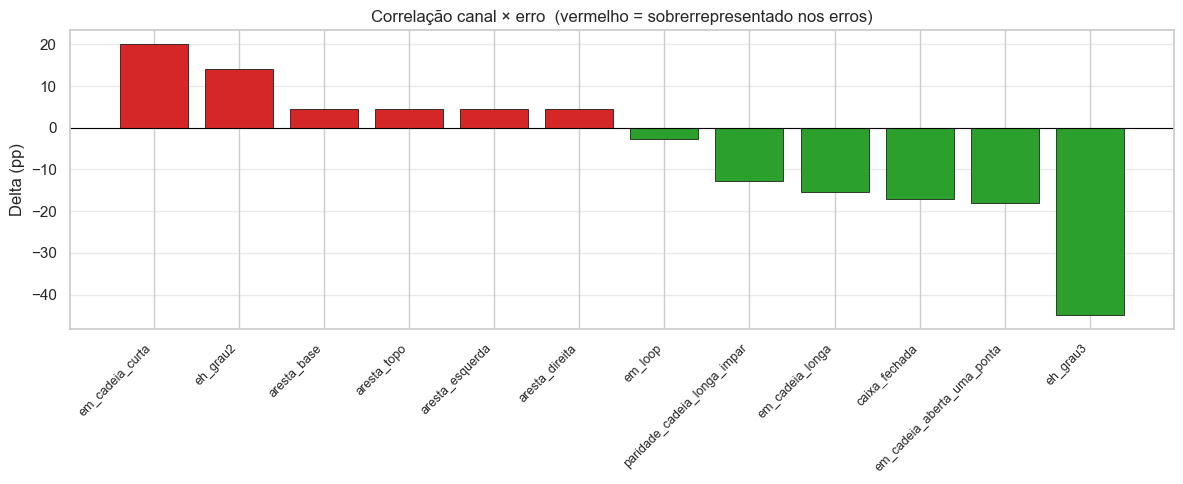

In [ ]:
# =========================================================================
# 7. CORRELAÇÃO CANAL x ERRO
# =========================================================================
erros_mask = ~pred_eh_otimo
n_erros    = int(erros_mask.sum())
n_total    = len(erros_mask)

rows_corr = []
for ki, nome_canal in enumerate(NOMES_CANAIS_REF):
    taxa_total = float(canal_presente[:, ki].mean())
    taxa_erros = float(canal_presente[erros_mask, ki].mean()) if n_erros > 0 else 0.0
    delta      = (taxa_erros - taxa_total) * 100
    rows_corr.append({'Canal': nome_canal,
                      'Total (%)': f'{taxa_total:.1%}',
                      'Em Erros (%)': f'{taxa_erros:.1%}',
                      'Delta (pp)': f'{delta:+.1f}'})

df_corr_report = pd.DataFrame(rows_corr).sort_values(
    'Delta (pp)', ascending=False, key=lambda s: s.str.replace('+', '').astype(float)
).set_index('Canal')

_iniciar_secao('correlacao')
_md_h(2, '7. Correlação Canal × Erro')
rprint(f'*Erros (OMA=0): {n_erros} de {n_total} ({n_erros/n_total:.1%}) no conjunto de Teste*')
rprint('*Delta positivo = canal sobrerrepresentado nos erros*\n')
_md_table(df_corr_report, index=True)
_md_sep()

# Visualização (não capturada no relatório)
df_corr_raw = pd.DataFrame(rows_corr)
df_corr_raw['_delta'] = df_corr_raw['Delta (pp)'].str.replace('+', '').astype(float)
df_corr_raw = df_corr_raw.sort_values('_delta', ascending=False)
colors = ['#d62728' if float(d) > 0 else '#2ca02c' for d in df_corr_raw['_delta']]
fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(df_corr_raw['Canal'], df_corr_raw['_delta'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(0, color='black', linewidth=0.8)
ax.set_ylabel('Delta (pp)')
ax.set_title('Correlação canal × erro  (vermelho = sobrerrepresentado nos erros)')
ax.set_xticklabels(df_corr_raw['Canal'], rotation=45, ha='right', fontsize=9)
ax.grid(axis='y', alpha=0.4)
plt.tight_layout()
plt.show()


## 8. Performance por Fase (Numérico)

| Fase                |      N | Top-1   | Top-3   | Top-5   | OMA    |
|:--------------------|-------:|:--------|:--------|:--------|:-------|
| Abertura (0-11)     | 753166 | 15.1%   | 21.4%   | 28.8%   | 87.1%  |
| 1a Metade (12-17)   | 410817 | 52.0%   | 73.4%   | 83.4%   | 80.3%  |
| 2a Metade (18-23)   | 410814 | 67.3%   | 88.2%   | 92.5%   | 98.8%  |
| Fase Quente (24-28) | 342342 | 65.3%   | 92.7%   | 97.4%   | 100.0% |
| Final (29-31)       | 136937 | 92.3%   | 100.0%  | 100.0%  | 100.0% |

*[Gráfico de barras por fase — ver notebook]*


---



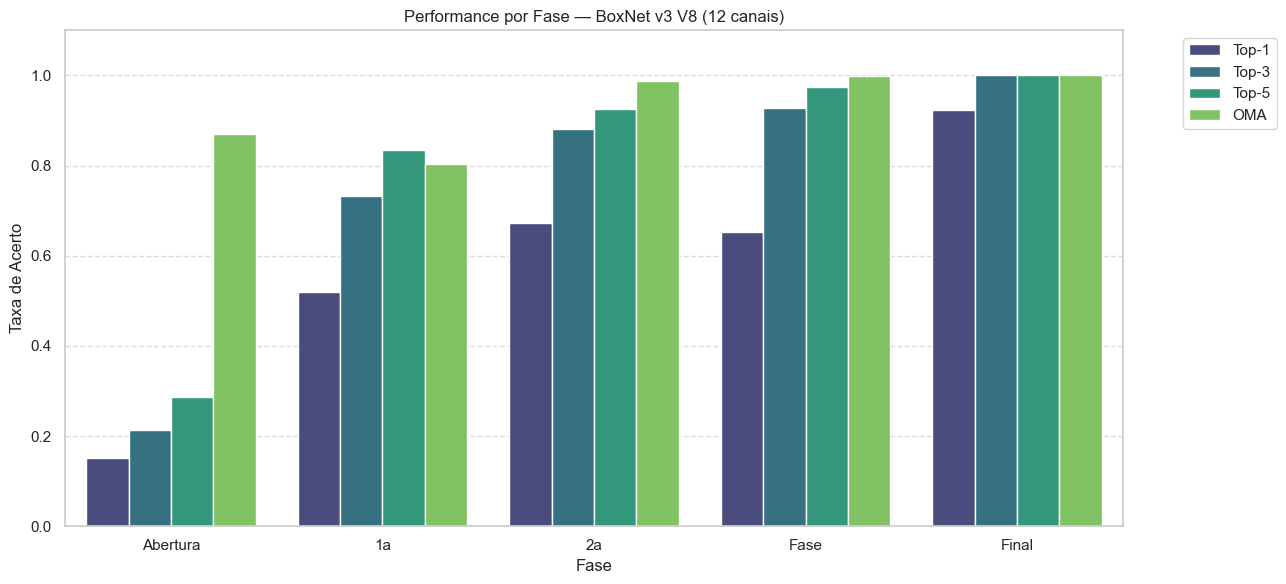

In [ ]:
# =========================================================================
# 8. VISUALIZAÇÃO POR FASE (Top-1 / Top-3 / Top-5 / OMA)
# =========================================================================
dados_fases_chart = []
rows_fases_num = []

for lo, hi, nome in fases:
    mask = (tracos_test >= lo) & (tracos_test <= hi)
    if mask.sum() == 0:
        continue
    t1 = (y_pred_idx[mask] == y_test_idx[mask]).mean()
    argsorted = np.argsort(y_pred_prob[mask], axis=1)
    t3 = (argsorted[:, -3:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    t5 = (argsorted[:, -5:] == y_test_idx[mask, np.newaxis]).any(axis=1).mean()
    oma_f = pred_eh_otimo[mask].mean()
    fase_nome = nome.split(' ')[0]
    dados_fases_chart += [
        {'Fase': fase_nome, 'Metrica': 'Top-1', 'Acuracia': t1},
        {'Fase': fase_nome, 'Metrica': 'Top-3', 'Acuracia': t3},
        {'Fase': fase_nome, 'Metrica': 'Top-5', 'Acuracia': t5},
        {'Fase': fase_nome, 'Metrica': 'OMA',   'Acuracia': oma_f},
    ]
    rows_fases_num.append({'Fase': nome, 'N': int(mask.sum()),
                           'Top-1': f'{t1:.1%}', 'Top-3': f'{t3:.1%}',
                           'Top-5': f'{t5:.1%}', 'OMA': f'{oma_f:.1%}'})

df_fases_num = pd.DataFrame(rows_fases_num).set_index('Fase')

_iniciar_secao('performance_fase')
_md_h(2, '8. Performance por Fase (Numérico)')
_md_table(df_fases_num)
rprint('*[Gráfico de barras por fase — ver notebook]*\n')
_md_sep()

# Gráfico (não capturado no relatório)
df_fases_chart = pd.DataFrame(dados_fases_chart)
plt.figure(figsize=(13, 6))
sns.barplot(data=df_fases_chart, x='Fase', y='Acuracia', hue='Metrica', palette='viridis')
plt.title(f'Performance por Fase — BoxNet v3 V8 ({K} canais)')
plt.ylim(0, 1.1)
plt.ylabel('Taxa de Acerto')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [ ]:
# =========================================================================
# 9. EXPORTACAO PARA TENSORFLOW LITE
# =========================================================================
with tf.device("/CPU:0"):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
tflite_model = converter.convert()

#nome_arquivo = f'pontinhos_pequeno_cnn_depth_11_e_20_{K}canais_valloss.tflite'
nome_arquivo = f'pontinhos_pequeno_cnn_depth_11_e_20_{K}canais_OVERFIT.tflite' # Teste de Overfit
tflite_path = os.path.join(RESULTADO_DIR, nome_arquivo)

with open(tflite_path, 'wb') as fout:
    fout.write(tflite_model)
print(f'Modelo salvo: {tflite_path} ({len(tflite_model)/1024:.1f} KB)')

# --- Report: exportacao ---
_iniciar_secao('exportacao')
_md_h(2, '9. Exportacao TFLite')
rprint('| Parametro | Valor |')
rprint('|-----------|-------|')
rprint(f'| Arquivo | `{nome_arquivo}` |')
rprint(f'| Caminho | `{tflite_path}` |')
rprint(f'| Tamanho | {len(tflite_model)/1024:.1f} KB |')
rprint(f'| Quantizacao | DEFAULT (float16 / dynamic range) |')
rprint()
_md_sep()

INFO:tensorflow:Assets written to: C:\Users\diondu\AppData\Local\Temp\tmpvlqxy4iv\assets


INFO:tensorflow:Assets written to: C:\Users\diondu\AppData\Local\Temp\tmpvlqxy4iv\assets


Modelo salvo: d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\resultados\jogo_pontinhos\pontinhos_pequeno_cnn_depth_11_e_20_12canais_valloss.tflite (90.5 KB)

## 9. Exportacao TFLite

| Parametro | Valor |
|-----------|-------|
| Arquivo | `pontinhos_pequeno_cnn_depth_11_e_20_12canais_valloss.tflite` |
| Caminho | `d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\resultados\jogo_pontinhos\pontinhos_pequeno_cnn_depth_11_e_20_12canais_valloss.tflite` |
| Tamanho | 90.5 KB |
| Quantizacao | DEFAULT (float16 / dynamic range) |


---



In [ ]:
# =========================================================================
# 10. EXPORTAR RELATORIO PARA MARKDOWN
# =========================================================================
from datetime import datetime

ts = datetime.now().strftime('%Y%m%d_%H%M%S')
#nome = f'pontinhos_pequeno_cnn_depth_11_e_20_{K}canais_valloss_treinamento_{ts}.md'
nome = f'pontinhos_pequeno_cnn_depth_11_e_20_{K}canais_OVERFIT_treinamento_{ts}.md' # Teste de Overfit
md_path = os.path.join(RESULTADO_DIR, nome)

with open(md_path, 'w', encoding='utf-8') as fmd:
    fmd.write(_report_buf.getvalue())
print(f'Relatorio salvo: {md_path} ({len(_report_buf.getvalue().encode())/1024:.1f} KB)')

Relatorio salvo: d:\Desenvolvimento\arena-sagaz\arena-sagaz-backend\resultados\jogo_pontinhos\pontinhos_pequeno_cnn_depth_11_e_20_12canais_valloss_treinamento_20260527_090244.md (14.6 KB)
